# Практические задания 1-5: предиктивная аналитика ветроэнергетической установки

Этот ноутбук является самостоятельным продолжением `Wind_Turbine_Tutorial_RU_ML.ipynb`.
Он использует CSV-файлы из папки `dataset`: `scada_data.csv`, `status_data.csv`, `fault_data.csv`.

Сначала повторяется минимальная подготовка данных из основного ноутбука: парсинг дат, пересечение временных периодов, разметка SCADA через `merge_asof`, удаление leakage-признаков и подготовка обучающей таблицы. После этого решаются задания 1-5.

## Практические задания

1. **Задание 1.** Постройте boxplot для канала `WEC: ava. reactive Power` в разрезе типов отказов. Что вы видите для класса `EF`?
2. **Задание 2.** Замените `SMOTE` на `BorderlineSMOTE` в pipeline. Сравните метрики до и после.
3. **Задание 3.** Постройте feature importance для тюнингованной модели LightGBM (`grid.best_estimator_.named_steps['lgbmclassifier'].feature_importances_`). Какие 5 признаков наиболее важны?
4. **Задание 4.** Реализуйте временную валидацию через `TimeSeriesSplit` вместо `StratifiedKFold`. Как изменились метрики? Объясните разницу.
5. **Задание 5.** Постройте PCA-проекцию признаков SCADA в 2D, раскрасьте точки по типу отказа. Видна ли визуальная разделимость классов?

## 0. Установка и импорт библиотек

В Google Colab сначала раскомментируйте ячейку установки. При локальном запуске зависимости можно поставить командой `python -m pip install -r requirements.txt`.

In [1]:
# !pip install -q imbalanced-learn lightgbm\n

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, TimeSeriesSplit, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.decomposition import PCA

from imblearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)
RANDOM_STATE = 42

## 1. Загрузка данных из `dataset`

Код ищет папку `dataset` рядом с ноутбуком, в текущей рабочей директории или в `/content/dataset` для Colab.

In [3]:
def find_data_dir():
    candidates = [
        Path("dataset"),
        Path("my collabs/part1/dataset"),
        Path("/content/dataset"),
    ]
    for candidate in candidates:
        if (candidate / "scada_data.csv").exists():
            return candidate
    raise FileNotFoundError("Не найдена папка dataset со scada_data.csv, status_data.csv, fault_data.csv")


DATA_DIR = find_data_dir()
print(f"Используем данные из: {DATA_DIR.resolve()}")

scada = pd.read_csv(DATA_DIR / "scada_data.csv")
status = pd.read_csv(DATA_DIR / "status_data.csv")
faults = pd.read_csv(DATA_DIR / "fault_data.csv")

scada["DateTime"] = pd.to_datetime(scada["DateTime"], errors="coerce")
status["Time"] = pd.to_datetime(status["Time"], dayfirst=True, errors="coerce")
faults["DateTime"] = pd.to_datetime(faults["DateTime"], errors="coerce")

scada = scada.sort_values("DateTime").reset_index(drop=True)
status = status.sort_values("Time").reset_index(drop=True)
faults = faults.sort_values("DateTime").reset_index(drop=True)

print("SCADA :", scada.shape)
print("Status:", status.shape)
print("Faults:", faults.shape)

Используем данные из: D:\ИТМО\Семестр 2\СистемыАльтерЭнерг\my collabs\part1\dataset


SCADA : (49027, 66)
Status: (1849, 9)
Faults: (553, 3)


## 2. Разметка SCADA по журналу отказов

SCADA записывается регулярно, а журнал отказов содержит отдельные события. Поэтому используем `pandas.merge_asof`: для каждой SCADA-записи ищется ближайший отказ в окне 10 минут. Если рядом отказа нет, ставится `NF` — нормальный режим.

In [4]:
common_start = max(scada["DateTime"].min(), status["Time"].min(), faults["DateTime"].min())
common_end = min(scada["DateTime"].max(), status["Time"].max(), faults["DateTime"].max())
in_common = (scada["DateTime"] >= common_start) & (scada["DateTime"] <= common_end)

scada_common = scada.loc[in_common].sort_values("DateTime").reset_index(drop=True)
faults_sorted = faults.sort_values("DateTime").reset_index(drop=True)

df_combine = pd.merge_asof(
    scada_common,
    faults_sorted[["DateTime", "Fault"]],
    on="DateTime",
    direction="nearest",
    tolerance=pd.Timedelta(minutes=10),
)
df_combine["Fault"] = df_combine["Fault"].fillna("NF")

print(f"Общий период: {common_start} ... {common_end}")
print(f"Размер объединенной таблицы: {df_combine.shape}")
print(df_combine["Fault"].value_counts())

Общий период: 2014-05-14 14:39:44 ... 2015-01-15 23:09:20
Размер объединенной таблицы: (35168, 67)
Fault
NF    34610
FF      210
EF      210
AF       79
GF       46
MF       13
Name: count, dtype: int64


## 3. Подготовка признаков

Класс `NF` сильно доминирует, поэтому оставляем 300 случайных нормальных записей и все записи с отказами. Затем удаляем признаки с возможной утечкой: время, мощность, выработку, часы работы, скорость ветра и служебные поля.

In [5]:
df_nf = df_combine[df_combine["Fault"] == "NF"].sample(300, random_state=RANDOM_STATE)
df_fault = df_combine[df_combine["Fault"] != "NF"]
df_balanced = pd.concat([df_nf, df_fault], axis=0).reset_index(drop=True)

drop_cols = [
    "DateTime", "Time", "Error",
    "WEC: ava. windspeed", "WEC: max. windspeed", "WEC: min. windspeed",
    "WEC: ava. Power", "WEC: max. Power", "WEC: min. Power",
    "WEC: ava. available P from wind",
    "WEC: ava. available P technical reasons",
    "WEC: ava. Available P force majeure reasons",
    "WEC: ava. Available P force external reasons",
    "WEC: Operating Hours", "WEC: Production kWh", "WEC: Production minutes",
    "ws_bin",
]
drop_cols = [c for c in drop_cols if c in df_balanced.columns]

train_df = df_balanced.drop(columns=drop_cols).dropna().reset_index(drop=True)
X = train_df.drop(columns=["Fault"])
y = train_df["Fault"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

print("После подвыборки NF:")
print(df_balanced["Fault"].value_counts())
print(f"Итоговая таблица: {train_df.shape}")
print(f"Признаков: {X.shape[1]}")

После подвыборки NF:
Fault
NF    300
FF    210
EF    210
AF     79
GF     46
MF     13
Name: count, dtype: int64
Итоговая таблица: (858, 51)
Признаков: 50


In [6]:
def make_lgbm_pipeline(sampler):
    return make_pipeline(
        sampler,
        StandardScaler(),
        LGBMClassifier(
            random_state=RANDOM_STATE,
            verbose=-1,
            n_estimators=80,
            num_leaves=12,
            reg_alpha=1,
            reg_lambda=1,
        ),
    )


scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
}
stratkfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## Задание 1. Boxplot реактивной мощности

Строим boxplot для `WEC: ava. reactive Power` по классам. Этот канал важен для электрических режимов: реактивная мощность часто меняется при проблемах возбуждения и сети.

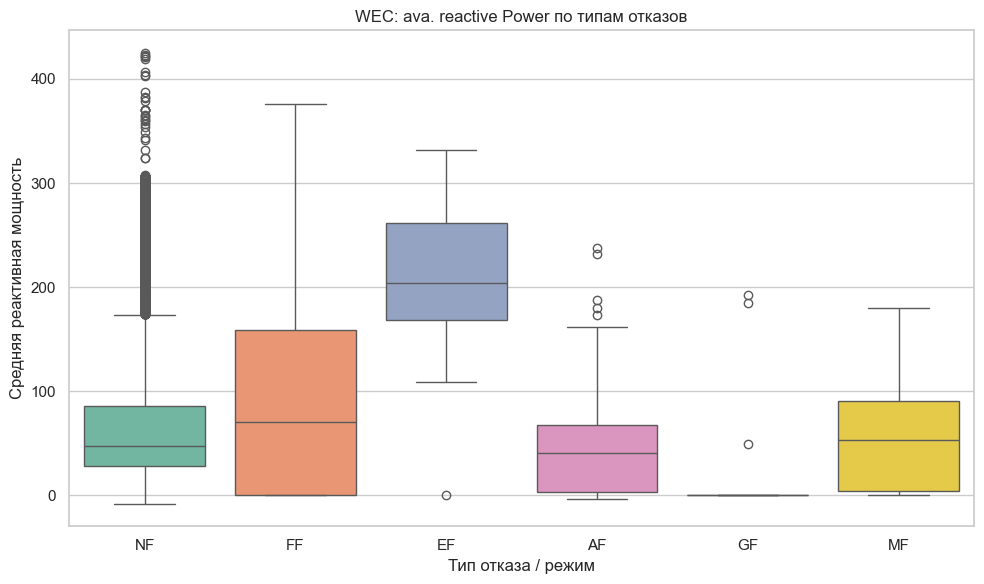

,count,mean,std,min,25%,50%,75%,max
Fault,,,,,,,,
NF,"34,610.0000",72.9300,75.4300,-8.0000,28.0000,47.0000,86.0000,425.0000
FF,210.0000,90.0100,100.8400,0.0000,0.0000,70.0000,159.0000,376.0000
EF,210.0000,205.9200,57.5900,0.0000,168.0000,204.0000,261.5000,332.0000
AF,79.0000,51.5300,55.7700,-3.0000,3.0000,41.0000,68.0000,238.0000
GF,46.0000,9.2600,39.3100,0.0000,0.0000,0.0000,0.0000,192.0000
MF,13.0000,61.1500,63.4400,0.0000,4.0000,53.0000,91.0000,180.0000


In [7]:
class_order = [c for c in ["NF", "FF", "EF", "AF", "GF", "MF"] if c in df_combine["Fault"].unique()]

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_combine,
    x="Fault",
    y="WEC: ava. reactive Power",
    order=class_order,
    palette="Set2",
)
plt.title("WEC: ava. reactive Power по типам отказов")
plt.xlabel("Тип отказа / режим")
plt.ylabel("Средняя реактивная мощность")
plt.tight_layout()
plt.show()

reactive_summary = df_combine.groupby("Fault")["WEC: ava. reactive Power"].describe().round(2)
reactive_summary.loc[class_order]

**Вывод по заданию 1.** На boxplot хорошо видно, что класс `EF` заметно отличается по реактивной мощности от большинства остальных режимов. Его значения в целом находятся выше, поэтому этот признак выглядит полезным для распознавания такого отказа. Еще можно заметить, что у некоторых классов разброс довольно большой, поэтому один только этот столбец не решает всю задачу, но как подсказка для анализа он выглядит сильным.

## Задание 2. SMOTE против BorderlineSMOTE

`SMOTE` генерирует синтетические точки между объектами миноритарного класса. `BorderlineSMOTE` делает акцент на объектах около границы классов.

In [8]:
def evaluate_pipeline(name, pipe):
    cv_scores = cross_validate(pipe, X_train, y_train, cv=stratkfold, scoring=scoring, n_jobs=1)
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    test_scores = {
        "accuracy": accuracy_score(y_test, pred),
        "precision_macro": precision_score(y_test, pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, pred, average="macro"),
    }
    row = {"model": name}
    for metric in test_scores:
        row[f"cv_{metric}"] = cv_scores[f"test_{metric}"].mean()
        row[f"test_{metric}"] = test_scores[metric]
    return row, pred


smote_pipe = make_lgbm_pipeline(SMOTE(random_state=RANDOM_STATE, k_neighbors=3))
borderline_pipe = make_lgbm_pipeline(BorderlineSMOTE(random_state=RANDOM_STATE, k_neighbors=3))

smote_row, y_pred_smote = evaluate_pipeline("SMOTE", smote_pipe)
borderline_row, y_pred_borderline = evaluate_pipeline("BorderlineSMOTE", borderline_pipe)

comparison = pd.DataFrame([smote_row, borderline_row]).set_index("model").round(4)
comparison

  File "C:\Users\Nick\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\Nick\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "C:\Users\Nick\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\Nick\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Nick\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


,cv_accuracy,test_accuracy,cv_precision_macro,test_precision_macro,cv_recall_macro,test_recall_macro,cv_f1_macro,test_f1_macro
model,,,,,,,,
SMOTE,0.8333,0.8721,0.8071,0.8531,0.7836,0.9009,0.7894,0.8684
BorderlineSMOTE,0.8450,0.8566,0.7987,0.8527,0.7780,0.8376,0.7834,0.8416


In [9]:
print("SMOTE classification report:")
print(classification_report(y_test, y_pred_smote, zero_division=0))

print("BorderlineSMOTE classification report:")
print(classification_report(y_test, y_pred_borderline, zero_division=0))

SMOTE classification report:
              precision    recall  f1-score   support

          AF       0.81      0.88      0.84        24
          EF       0.78      0.95      0.86        63
          FF       0.93      0.79      0.85        63
          GF       1.00      0.93      0.96        14
          MF       0.67      1.00      0.80         4
          NF       0.94      0.86      0.90        90

    accuracy                           0.87       258
   macro avg       0.85      0.90      0.87       258
weighted avg       0.88      0.87      0.87       258

BorderlineSMOTE classification report:
              precision    recall  f1-score   support

          AF       0.86      0.75      0.80        24
          EF       0.76      0.95      0.85        63
          FF       0.92      0.78      0.84        63
          GF       0.93      0.93      0.93        14
          MF       0.75      0.75      0.75         4
          NF       0.90      0.87      0.88        90

    accur

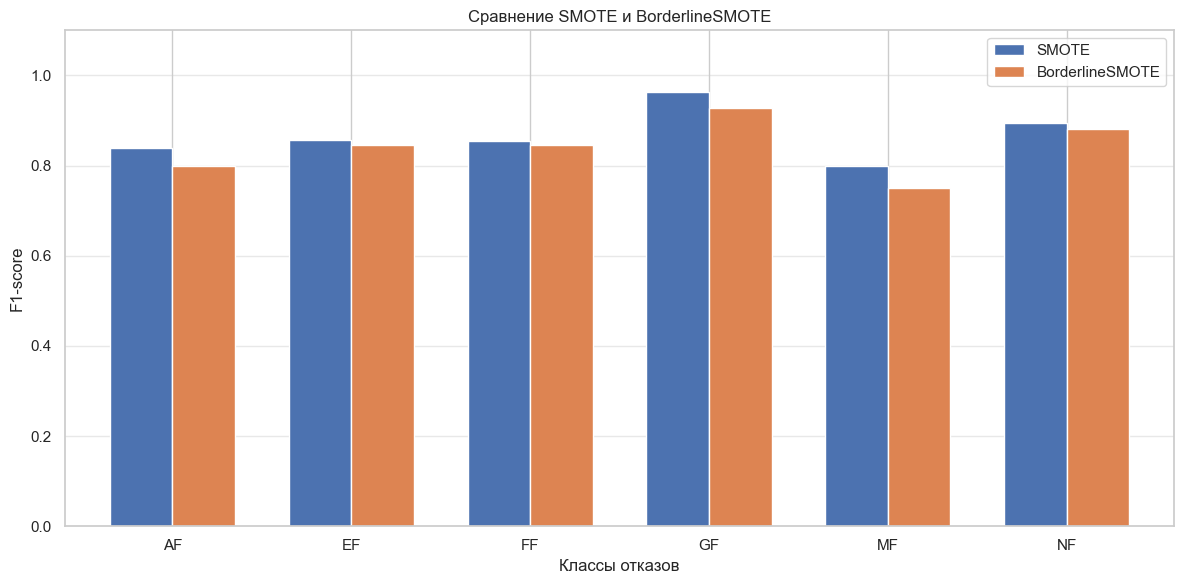

,SMOTE,BorderlineSMOTE
AF,0.8400,0.8000
EF,0.8571,0.8451
FF,0.8547,0.8448
GF,0.9630,0.9286
MF,0.8000,0.7500
NF,0.8953,0.8814


In [10]:
# График сравнения F1-score по классам для SMOTE и BorderlineSMOTE
smote_report = classification_report(y_test, y_pred_smote, output_dict=True, zero_division=0)
borderline_report = classification_report(y_test, y_pred_borderline, output_dict=True, zero_division=0)

f1_classes = [cls for cls in ["AF", "EF", "FF", "GF", "MF", "NF"] if cls in smote_report and cls in borderline_report]
f1_compare = pd.DataFrame({
    "SMOTE": [smote_report[cls]["f1-score"] for cls in f1_classes],
    "BorderlineSMOTE": [borderline_report[cls]["f1-score"] for cls in f1_classes],
}, index=f1_classes)

ax = f1_compare.plot(kind="bar", figsize=(12, 6), width=0.7)
ax.set_title("Сравнение SMOTE и BorderlineSMOTE")
ax.set_xlabel("Классы отказов")
ax.set_ylabel("F1-score")
ax.set_ylim(0, 1.1)
ax.grid(True, axis="y", alpha=0.45)
ax.legend(title="")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

f1_compare.round(4)

**Вывод по заданию 2.** По графику видно, что `SMOTE` и `BorderlineSMOTE` дают близкие результаты, но выигрывают не везде одинаково. На одних классах немного лучше выглядит обычный `SMOTE`, на других `BorderlineSMOTE` подтягивает результат. Поэтому нельзя просто сказать, что второй метод всегда лучше первого. В этой работе логичнее сравнивать их по каждому классу отдельно: для диагностики важно не только среднее качество, но и то, какие именно отказы модель начинает путать меньше.

Еще заметно, что редкие классы ведут себя менее стабильно. Это ожидаемо: когда примеров мало, метод балансировки может помочь, но он не заменяет реальные данные. Поэтому график полезен именно как проверка: стало ли лучше по нужным классам, а не просто выросла ли одна общая метрика.

## Задание 3. Feature importance тюнингованной LightGBM

Выполним небольшой `GridSearchCV`, затем достанем обученный классификатор из pipeline через `grid.best_estimator_.named_steps['lgbmclassifier']`.

In [11]:
base_grid_pipe = make_pipeline(
    SMOTE(random_state=RANDOM_STATE, k_neighbors=3),
    StandardScaler(),
    LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
)

param_grid = {
    "lgbmclassifier__n_estimators": [16, 24],
    "lgbmclassifier__num_leaves": [6, 8],
    "lgbmclassifier__reg_alpha": [1, 1.5],
    "lgbmclassifier__reg_lambda": [1, 1.5],
    "lgbmclassifier__boosting_type": ["gbdt"],
}

grid = GridSearchCV(
    base_grid_pipe,
    param_grid=param_grid,
    cv=stratkfold,
    scoring="f1_macro",
    n_jobs=1,
    verbose=0,
)
grid.fit(X_train, y_train)

print("Лучшие параметры:")
for key, value in grid.best_params_.items():
    print(f"{key}: {value}")
print(f"Лучший CV macro F1: {grid.best_score_:.4f}")

best_pred = grid.predict(X_test)
print(f"Test macro F1: {f1_score(y_test, best_pred, average='macro'):.4f}")

Лучшие параметры:
lgbmclassifier__boosting_type: gbdt
lgbmclassifier__n_estimators: 24
lgbmclassifier__num_leaves: 8
lgbmclassifier__reg_alpha: 1
lgbmclassifier__reg_lambda: 1.5
Лучший CV macro F1: 0.7590
Test macro F1: 0.7823


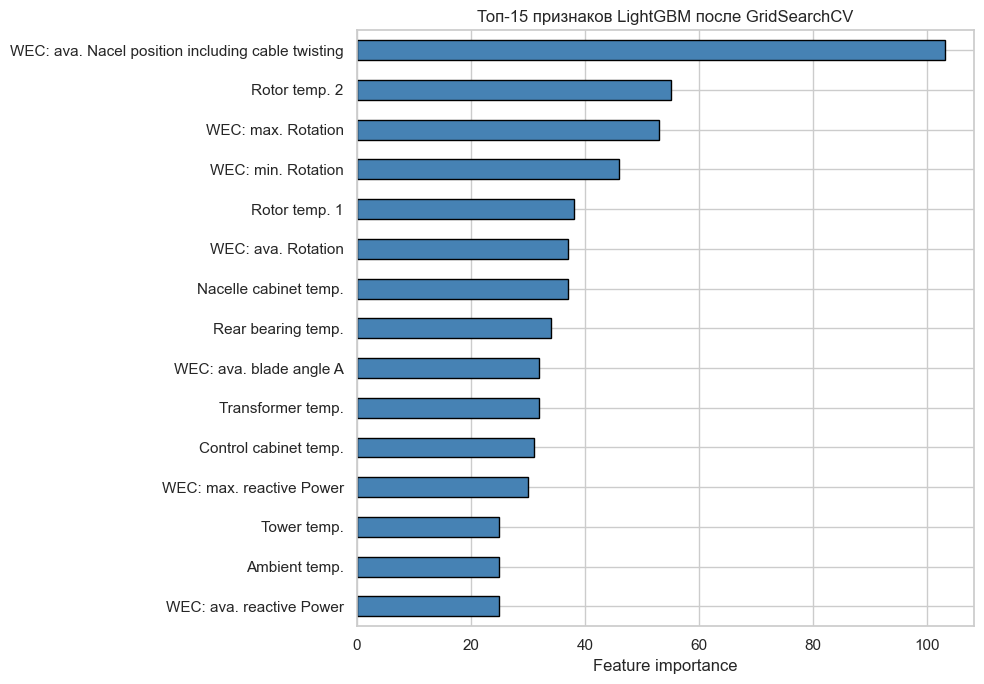

Топ-5 признаков:
WEC: ava. Nacel position including cable twisting    103
Rotor temp. 2                                         55
WEC: max. Rotation                                    53
WEC: min. Rotation                                    46
Rotor temp. 1                                         38


In [12]:
best_lgbm = grid.best_estimator_.named_steps["lgbmclassifier"]
importance = pd.Series(best_lgbm.feature_importances_, index=X_train.columns).sort_values(ascending=False)

top15 = importance.head(15)
plt.figure(figsize=(10, 7))
top15[::-1].plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Топ-15 признаков LightGBM после GridSearchCV")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()

print("Топ-5 признаков:")
print(importance.head(5).to_string())

**Вывод по заданию 3.** Важные признаки получились вполне понятными по смыслу: вверху оказались положение гондолы, обороты и температуры ротора. Это похоже на нормальную картину, потому что такие параметры связаны с режимом работы турбины и состоянием ее основных узлов. Если бы в топе оказались только случайные служебные столбцы, это было бы подозрительно.

По этому графику удобно объяснять модель: она смотрит не на один единственный датчик, а собирает картину из нескольких физических параметров. При этом feature importance не стоит воспринимать как абсолютную истину. Это скорее подсказка, какие каналы стоит проверить внимательнее.

## Задание 4. Временная валидация через TimeSeriesSplit

`StratifiedKFold` перемешивает данные и проверяет модель на случайных фолдах. Для временных рядов это может быть слишком оптимистично. `TimeSeriesSplit` сохраняет порядок: обучаемся на прошлом, проверяемся на будущем.

In [13]:
train_ts = df_balanced.sort_values("DateTime").drop(columns=drop_cols).dropna().reset_index(drop=True)
X_ts = train_ts.drop(columns=["Fault"])
y_ts = train_ts["Fault"]

time_cv = TimeSeriesSplit(n_splits=5)
ts_rows = []

for fold, (train_idx, test_idx) in enumerate(time_cv.split(X_ts), start=1):
    X_tr, X_val = X_ts.iloc[train_idx], X_ts.iloc[test_idx]
    y_tr, y_val = y_ts.iloc[train_idx], y_ts.iloc[test_idx]

    model = grid.best_estimator_
    model.fit(X_tr, y_tr)
    pred = model.predict(X_val)

    ts_rows.append({
        "fold": fold,
        "train_classes": dict(y_tr.value_counts()),
        "test_classes": dict(y_val.value_counts()),
        "accuracy": accuracy_score(y_val, pred),
        "precision_macro": precision_score(y_val, pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_val, pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_val, pred, average="macro"),
    })

ts_result = pd.DataFrame(ts_rows)
display(ts_result[["fold", "accuracy", "precision_macro", "recall_macro", "f1_macro"]].round(4))
print("Средние метрики TimeSeriesSplit:")
print(ts_result[["accuracy", "precision_macro", "recall_macro", "f1_macro"]].mean().round(4))

print("\nРаспределение классов по фолдам:")
for row in ts_rows:
    print(f"fold {row['fold']}: train={row['train_classes']} | test={row['test_classes']}")

,fold,accuracy,precision_macro,recall_macro,f1_macro
0,1,0.6573,0.3616,0.4125,0.3549
1,2,0.1608,0.3113,0.1388,0.1421
2,3,0.5664,0.3714,0.2970,0.2986
3,4,0.3497,0.2524,0.4150,0.3095
4,5,0.3986,0.2408,0.3047,0.2363


Средние метрики TimeSeriesSplit:
accuracy          0.4266
precision_macro   0.3075
recall_macro      0.3136
f1_macro          0.2683
dtype: float64

Распределение классов по фолдам:
fold 1: train={'NF': 90, 'AF': 26, 'EF': 10, 'GF': 6, 'MF': 6, 'FF': 5} | test={'NF': 85, 'AF': 47, 'EF': 9, 'FF': 2}
fold 2: train={'NF': 175, 'AF': 73, 'EF': 19, 'FF': 7, 'GF': 6, 'MF': 6} | test={'EF': 80, 'NF': 31, 'FF': 21, 'MF': 7, 'GF': 4}
fold 3: train={'NF': 206, 'EF': 99, 'AF': 73, 'FF': 28, 'MF': 13, 'GF': 10} | test={'EF': 94, 'NF': 30, 'FF': 10, 'GF': 9}
fold 4: train={'NF': 236, 'EF': 193, 'AF': 73, 'FF': 38, 'GF': 19, 'MF': 13} | test={'FF': 76, 'NF': 50, 'EF': 17}
fold 5: train={'NF': 286, 'EF': 210, 'FF': 114, 'AF': 73, 'GF': 19, 'MF': 13} | test={'FF': 96, 'GF': 27, 'NF': 14, 'AF': 6}


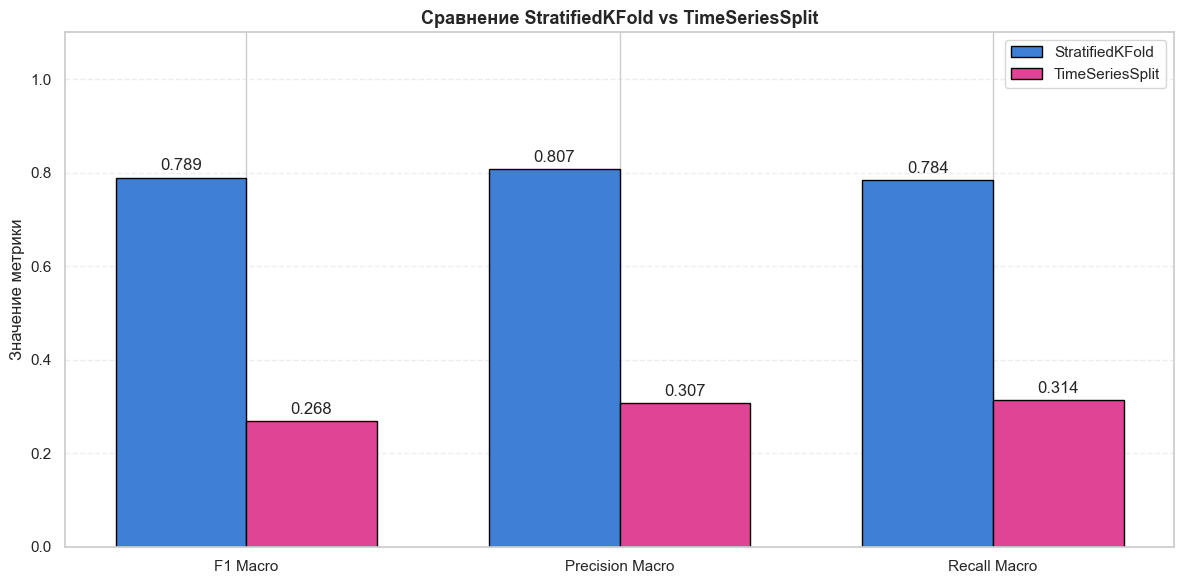

,StratifiedKFold,TimeSeriesSplit
F1 Macro,0.7894,0.2683
Precision Macro,0.8071,0.3075
Recall Macro,0.7836,0.3136


In [14]:
# Сравнение StratifiedKFold и TimeSeriesSplit по трем macro-метрикам
metric_order = ["F1 Macro", "Precision Macro", "Recall Macro"]

stratified_values = [
    smote_row["cv_f1_macro"],
    smote_row["cv_precision_macro"],
    smote_row["cv_recall_macro"],
]
timeseries_means = ts_result[["f1_macro", "precision_macro", "recall_macro"]].mean()
timeseries_values = [
    timeseries_means["f1_macro"],
    timeseries_means["precision_macro"],
    timeseries_means["recall_macro"],
]

x = np.arange(len(metric_order))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars_strat = ax.bar(
    x - width / 2,
    stratified_values,
    width,
    label="StratifiedKFold",
    color="#3F7FD5",
    edgecolor="black",
)
bars_time = ax.bar(
    x + width / 2,
    timeseries_values,
    width,
    label="TimeSeriesSplit",
    color="#E04495",
    edgecolor="black",
)

ax.set_title("Сравнение StratifiedKFold vs TimeSeriesSplit", fontsize=13, fontweight="bold")
ax.set_ylabel("Значение метрики")
ax.set_xticks(x)
ax.set_xticklabels(metric_order)
ax.set_ylim(0, 1.1)
ax.grid(True, axis="y", alpha=0.35, linestyle="--")
ax.legend()

for bars in [bars_strat, bars_time]:
    ax.bar_label(bars, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

pd.DataFrame(
    {
        "StratifiedKFold": stratified_values,
        "TimeSeriesSplit": timeseries_values,
    },
    index=metric_order,
).round(4)

**Вывод по заданию 4.** После перехода к `TimeSeriesSplit` качество выглядит заметно слабее, чем при случайном разбиении. Это нормальная ситуация: теперь модель не получает перемешанные похожие куски данных, а учится на более раннем периоде и проверяется на более позднем. Такой вариант ближе к реальности, потому что в жизни мы тоже не знаем будущие режимы заранее.

На графике трех macro-метрик видно, что показатели держатся не очень высоко и между ними есть разница. Это говорит о том, что модель не одинаково уверенно находит все типы отказов. Для учебной работы это хороший результат для обсуждения: случайное разбиение выглядит красивее, но временная проверка честнее показывает, что задача сложная.

## Задание 5. PCA-проекция SCADA-признаков в 2D

PCA сжимает многомерные признаки в две главные компоненты, которые сохраняют максимум линейной дисперсии. Это не классификатор, а способ посмотреть, есть ли грубая визуальная разделимость классов.

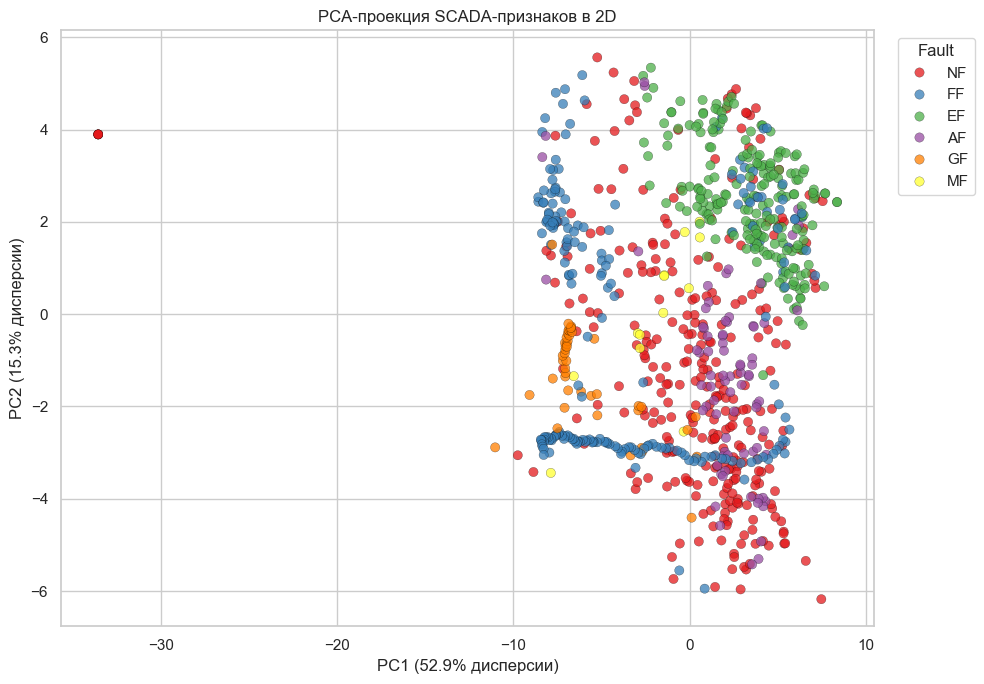

Доля объясненной дисперсии:
PC1   0.5291
PC2   0.1529
dtype: float64


In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Fault": y.values,
})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Fault",
    hue_order=class_order,
    palette="Set1",
    s=45,
    alpha=0.75,
    edgecolor="black",
    linewidth=0.2,
)
plt.title("PCA-проекция SCADA-признаков в 2D")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% дисперсии)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% дисперсии)")
plt.legend(title="Fault", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("Доля объясненной дисперсии:")
print(pd.Series(pca.explained_variance_ratio_, index=["PC1", "PC2"]).round(4))

**Вывод по заданию 5.** На PCA-графике классы не разделяются на аккуратные отдельные группы. Часть точек разных классов лежит рядом и пересекается, поэтому по двум главным осям нельзя просто провести линию и идеально отделить один отказ от другого. Это объясняет, почему задаче нужна более сложная модель.

При этом график все равно полезен. Он показывает общую форму данных: где есть плотные области, где есть выбросы, какие классы выглядят похожими. То есть PCA здесь больше помогает понять данные глазами, чем сразу получить готовое решение.

## Итог

В этой практике получилось пройти весь путь: загрузить данные, связать SCADA с журналом отказов, подготовить признаки, сравнить варианты балансировки, посмотреть важные признаки, проверить модель по времени и сделать PCA-график.

Главное наблюдение: красивые средние метрики не всегда означают, что модель реально хорошо понимает все отказы. Некоторые классы распознаются легче, некоторые постоянно смешиваются с другими. Поэтому полезнее смотреть не только на одну общую оценку, а на графики по классам и на временную проверку.

Если говорить простыми словами, модель уже находит часть закономерностей, но датасет сложный: классы пересекаются, редких отказов мало, а поведение турбины меняется со временем. Поэтому лучший вывод из работы не в том, что одна модель «идеальная», а в том, что мы научились видеть, где она работает уверенно, а где ей пока не хватает данных.